In [1]:
# Importing the lib
import numpy as np          # for random numbers and math
import pandas as pd         # for working with data in table form
import matplotlib.pyplot as plt  # for making charts
import seaborn as sns       # makes matplotlib charts look nicer
from scipy import stats     # for the statistical test at the end

from statsmodels.stats.proportion import proportions_ztest

In [2]:
# CREATING  THE DATASET
# Since I don't have real data, I'm generating synthetic data.
# The conversion rates are based on real e-commerce benchmarks.

import numpy as np
import pandas as pd

# np.random.seed() makes the "random" numbers reproducible
# Every run gives the same result — like saving a game slot
# .isnull().sum() counts empty cells per column
# alternative="larger" = one-tailed test (is treatment BETTER, not just different
np.random.seed(42)

# How many users in each group
n_users = 5000

# GROUP A: Control (old design) 

# np.random.binomial(1, 0.12, n_users) simulates a coin flip
# for each user — but instead of 50/50, the chance of "heads"
# (converting) is 12%. Each user either converts (1) or doesn't (0).

group_a = pd.DataFrame({
    "user_id"  : range(1, n_users + 1),
    "group"    : "control",
    "converted": np.random.binomial(1, 0.12, n_users),
    "device"   : np.random.choice(
                     ["mobile", "desktop", "tablet"],
                     n_users,
                     p=[0.55, 0.38, 0.07]  # mobile is most common
                 )
})

# ── GROUP B: Treatment (new design) 

group_b = pd.DataFrame({
    "user_id"  : range(n_users + 1, 2 * n_users + 1),
    "group"    : "treatment",
    "converted": np.random.binomial(1, 0.15, n_users),  # 15% rate
    "device"   : np.random.choice(
                     ["mobile", "desktop", "tablet"],
                     n_users,
                     p=[0.55, 0.38, 0.07]
                 )
})

# COMBINE BOTH GROUPS 

# pd.concat stacks the two tables on top of each other
# ignore_index=True resets the row numbers cleanly
df = pd.concat([group_a, group_b], ignore_index=True)

# Save it — this is my raw data file
df.to_csv("ab_test_data.csv", index=False)

print("Dataset created!")
print("Total rows:", len(df))
print("\nFirst 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())

Dataset created!
Total rows: 10000

First 5 rows:
   user_id    group  converted   device
0        1  control          0   mobile
1        2  control          1   mobile
2        3  control          0  desktop
3        4  control          0   mobile
4        5  control          0  desktop

Last 5 rows:
      user_id      group  converted   device
9995     9996  treatment          0  desktop
9996     9997  treatment          0   mobile
9997     9998  treatment          0   mobile
9998     9999  treatment          0   mobile
9999    10000  treatment          0   mobile


In [3]:
from statsmodels.stats.power import NormalIndPower

effect_size = 0.03   # the smallest improvement we care about (3%)
alpha       = 0.05   # false positive risk
power       = 0.80   # 80% chance of detecting the effect if real

analysis = NormalIndPower()
n_required = analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    alternative='larger'
)
print(f"Users needed per group: {int(n_required) + 1}")
# If this number is ≤ 5000, our sample size is sufficient

Users needed per group: 13740


In [4]:
df.head()

,user_id,group,converted,device
0,1,control,0,mobile
1,2,control,1,mobile
2,3,control,0,desktop
3,4,control,0,mobile
4,5,control,0,desktop


In [5]:
df["converted"].mean()

np.float64(0.1371)

In [6]:
df.groupby("group")["converted"].mean()

group
control      0.1156
treatment    0.1586
Name: converted, dtype: float64

In [7]:
#  STEP 3: DATA CLEANING & VALIDATION
#
# Before doing any analysis, I need to check the data quality.
# I learned that skipping this step leads to wrong conclusions.
# Even though I generated this data myself, I'm treating it
# like real data — because that's good practice.

print("BASIC INFO")

# .shape gives me (rows, columns) — a quick sanity check
print("Shape:", df.shape)

# .dtypes tells me what kind of data is in each column
# I want: user_id = int, group = object, converted = int, device = object
print("\nColumn types:")
print(df.dtypes)


print("CHECKING FOR MISSING VALUES")

# .isnull().sum() counts empty cells per column
# In real data, missing values are very common and dangerous
missing = df.isnull().sum()
print(missing)

if missing.sum() == 0:
    print("\n✓ No missing values found.")
else:
    print("\n⚠ Missing values found — need to handle these.")

print("CHECKING FOR DUPLICATE USERS")


# A user should only appear once in an A/B test
# If they appear twice, we don't know which group they truly belong to
duplicates = df["user_id"].duplicated().sum()
print("Duplicate user IDs:", duplicates)

if duplicates == 0:
    print("✓ No duplicates found.")
else:
    print("⚠ Duplicates found — need to drop them.")
    df = df.drop_duplicates(subset="user_id")


print("CHECKING GROUP BALANCE")

# Both groups should have roughly equal users
# A big imbalance would make the comparison unfair
print(df["group"].value_counts())

# I also want to make sure 'converted' only has 0 and 1
# Any other value would be a data error
print("\nUnique values in 'converted':", df["converted"].unique())

if set(df["converted"].unique()) == {0, 1}:
    print("✓ Converted column looks correct.")
else:
    print("⚠ Unexpected values in converted column!")



print("DATA CLEANING COMPLETE")


BASIC INFO
Shape: (10000, 4)

Column types:
user_id       int64
group        object
converted     int32
device       object
dtype: object
CHECKING FOR MISSING VALUES
user_id      0
group        0
converted    0
device       0
dtype: int64

✓ No missing values found.
CHECKING FOR DUPLICATE USERS
Duplicate user IDs: 0
✓ No duplicates found.
CHECKING GROUP BALANCE
group
control      5000
treatment    5000
Name: count, dtype: int64

Unique values in 'converted': [0 1]
✓ Converted column looks correct.
DATA CLEANING COMPLETE


In [8]:
from scipy.stats import chisquare

# Count how many users ended up in each group
observed_counts = df['group'].value_counts().sort_index().values
expected_counts = [len(df) / 2, len(df) / 2]   # perfectly equal split

chi2, srm_p = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print("=== SRM CHECK ===")
print(f"Control users  : {observed_counts[0]}")
print(f"Treatment users: {observed_counts[1]}")
print(f"Chi² statistic : {chi2:.4f}")
print(f"P-value        : {srm_p:.4f}")

if srm_p < 0.01:
    print("⚠ WARNING: SRM detected — randomization may be broken!")
else:
    print("✓ No SRM — groups are balanced, experiment is valid.")

=== SRM CHECK ===
Control users  : 5000
Treatment users: 5000
Chi² statistic : 0.0000
P-value        : 1.0000
✓ No SRM — groups are balanced, experiment is valid.


In [16]:
# STEP 4: EXPLORATORY DATA ANALYSIS 
#
# Before jumping to statistics or charts, I want to understand
# the data in plain numbers first. I learned that visualizing
# before understanding the raw numbers is a common beginner mistake.


print("CONVERSION SUMMARY BY GROUP")


# I'm building a summary table using groupby + agg
# agg() lets me calculate multiple things at once
summary = df.groupby("group").agg(
    total_users  = ("user_id",   "count"),  # how many users
    conversions  = ("converted", "sum"),    # how many bought
    conv_rate    = ("converted", "mean")    # conversion rate
)

# round to 4 decimal places for clean reading
summary["conv_rate"] = summary["conv_rate"].round(4)
print(summary)


# ── CALCULATE THE KEY NUMBERS ────────────────────────────────

cr_control   = df[df["group"] == "control"]["converted"].mean()
cr_treatment = df[df["group"] == "treatment"]["converted"].mean()

# Absolute difference: simply treatment minus control
absolute_diff = cr_treatment - cr_control

# Relative uplift: how much % better is treatment vs control?
# Formula: (new - old) / old * 100
relative_uplift = (cr_treatment - cr_control) / cr_control * 100


print("\nKEY METRICS")

print(f"Control conversion rate:    {cr_control*100:.2f}%")
print(f"Treatment conversion rate:  {cr_treatment*100:.2f}%")
print(f"Absolute difference:        +{absolute_diff*100:.2f}%")
print(f"Relative uplift:            +{relative_uplift:.2f}%")


# BREAKDOWN BY DEVICE 
# I wanted to go one level deeper — does the new design work
# better on some devices than others? This is called segmentation.
# I learned this is something analysts do to find hidden patterns.

print("\nCONVERSION RATE BY DEVICE")

device_summary = df.groupby(["device", "group"])["converted"].mean().round(4) * 100
print(device_summary.unstack())  # .unstack() makes it a readable side-by-side table

CONVERSION SUMMARY BY GROUP
           total_users  conversions  conv_rate
group                                         
control           5000          578     0.1156
treatment         5000          793     0.1586

KEY METRICS
Control conversion rate:    11.56%
Treatment conversion rate:  15.86%
Absolute difference:        +4.30%
Relative uplift:            +37.20%

CONVERSION RATE BY DEVICE
group    control  treatment
device                     
desktop    12.15      16.25
mobile     11.27      15.03
tablet     10.92      20.06


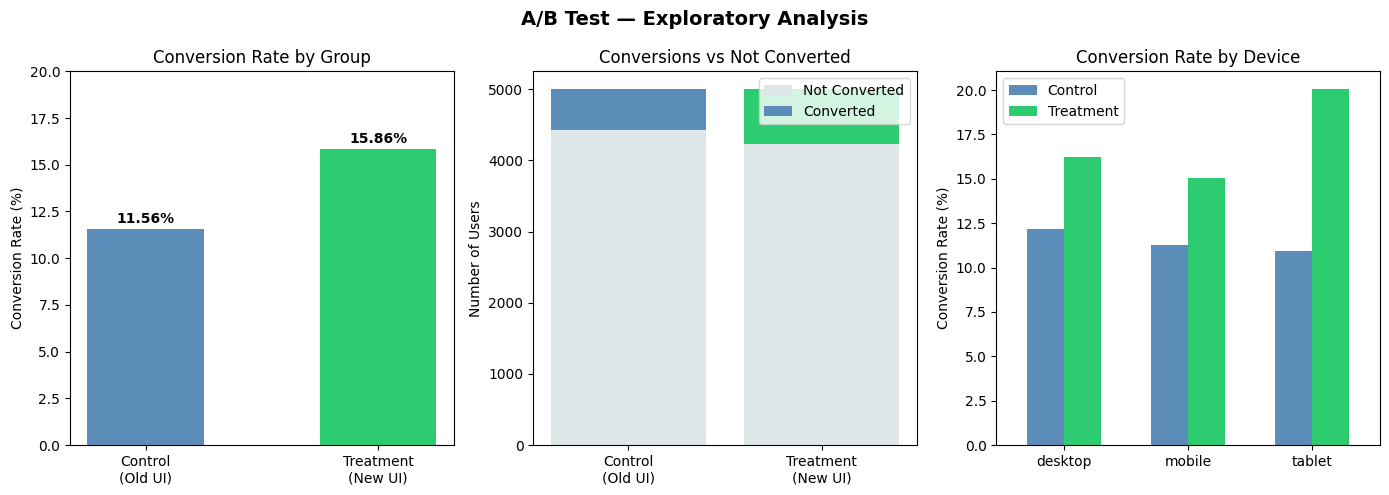

Charts saved.


In [10]:
# ── STEP 4B: VISUALIZATIONS ──────────────────────────────────
#
# I'm keeping the charts simple and readable.
# I didn't try to make them fancy — I focused on making them clear.
# I'm making 3 charts: conversion rate comparison, conversion
# counts, and device breakdown.

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("A/B Test — Exploratory Analysis", fontsize=14, fontweight="bold")

# ── Chart 1: Conversion Rate Bar Chart ──────────────────────
ax1 = axes[0]

groups = ["Control\n(Old UI)", "Treatment\n(New UI)"]
rates  = [cr_control * 100, cr_treatment * 100]
colors = ["#5B8DB8", "#2ecc71"]

bars = ax1.bar(groups, rates, color=colors, width=0.5)
ax1.set_title("Conversion Rate by Group")
ax1.set_ylabel("Conversion Rate (%)")
ax1.set_ylim(0, 20)

# Add the percentage label on top of each bar
# I learned this makes charts much easier to read at a glance
for bar, rate in zip(bars, rates):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,  # x position: center of bar
        bar.get_height() + 0.3,              # y position: just above bar
        f"{rate:.2f}%",                      # the label text
        ha="center", fontweight="bold"
    )


# ── Chart 2: Actual Conversion Counts ───────────────────────
# I added this because rates alone don't show volume
ax2 = axes[1]

conversions     = [578, 764]
non_conversions = [5000-578, 5000-764]

ax2.bar(groups, non_conversions, color="#dfe6e9", label="Not Converted")
ax2.bar(groups, conversions, bottom=non_conversions, color=colors, label="Converted")
ax2.set_title("Conversions vs Not Converted")
ax2.set_ylabel("Number of Users")
ax2.legend()


# ── Chart 3: Conversion Rate by Device ──────────────────────
ax3 = axes[2]

# I'm using the device_summary I calculated above
device_conv = df.groupby(["device", "group"])["converted"].mean() * 100
device_conv = device_conv.unstack()
device_conv.plot(kind="bar", ax=ax3, color=colors, width=0.6)

ax3.set_title("Conversion Rate by Device")
ax3.set_ylabel("Conversion Rate (%)")
ax3.set_xlabel("")
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
ax3.legend(["Control", "Treatment"])

plt.tight_layout()
plt.savefig("eda_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Charts saved.")

In [11]:
# STEP 5: STATISTICAL TEST
#
# Now I test whether the difference in conversion rates is
# statistically significant or could just be due to chance.
#
# I'm using a Two-Proportion Z-Test because:
# - I'm comparing two proportions (conversion rates)
# - Both sample sizes are large (n=5000 each)
# - Each user independently either converts or doesn't

from statsmodels.stats.proportion import proportions_ztest
import numpy as np

# GATHER THE NUMBERS I NEED 

# Number of users in each group
n_control   = df[df["group"] == "control"]["converted"].count()
n_treatment = df[df["group"] == "treatment"]["converted"].count()

# Number of conversions in each group
conv_control   = df[df["group"] == "control"]["converted"].sum()
conv_treatment = df[df["group"] == "treatment"]["converted"].sum()


print("INPUTS TO THE TEST")

print(f"Control   — users: {n_control},  conversions: {conv_control}")
print(f"Treatment — users: {n_treatment}, conversions: {conv_treatment}")


#  RUN THE Z-TEST 
#
# proportions_ztest needs:
# count = array of conversions [treatment, control]
# nobs  = array of total users  [treatment, control]
#
# alternative="larger" means our H1 is: treatment > control
# This is a one-tailed test — we only care if new design is BETTER
# not just DIFFERENT

count = np.array([conv_treatment, conv_control])
nobs  = np.array([n_treatment,    n_control])

z_stat, p_value = proportions_ztest(count, nobs, alternative="larger")


print("TEST RESULTS")

print(f"Z-statistic : {z_stat:.4f}")
print(f"P-value     : {p_value:.6f}")


# MAKE THE DECISION 
#
# Alpha is my significance threshold — standard in industry is 0.05
# If p-value is below this, I reject the null hypothesis

alpha = 0.05

print("DECISION")
print(f"Alpha (threshold) : {alpha}")
print(f"P-value           : {p_value:.6f}")
print()

if p_value < alpha:
    print("✓ p-value < 0.05")
    print("→ REJECT the Null Hypothesis")
    print("→ The new design significantly improves conversion rate.")
else:
    print("✗ p-value ≥ 0.05")
    print("→ FAIL TO REJECT the Null Hypothesis")
    print("→ Not enough evidence that the new design works.")


# CONFIDENCE INTERVAL
#
# The p-value tells me IF there's an effect.
# The confidence interval tells me HOW BIG the effect is.
# This is what the business team actually cares about.

cr_control   = conv_control / n_control
cr_treatment = conv_treatment / n_treatment

diff      = cr_treatment - cr_control
std_error = np.sqrt(
    (cr_control * (1 - cr_control) / n_control) +
    (cr_treatment * (1 - cr_treatment) / n_treatment)
)

ci_lower = diff - 1.96 * std_error
ci_upper = diff + 1.96 * std_error


print("95% CONFIDENCE INTERVAL")

print(f"Observed difference : +{diff*100:.2f}%")
print(f"95% CI              : [{ci_lower*100:.2f}%,  {ci_upper*100:.2f}%]")
print()
print("Meaning: We are 95% confident the true improvement")
print(f"in conversion rate is between {ci_lower*100:.2f}% and {ci_upper*100:.2f}%.")

INPUTS TO THE TEST
Control   — users: 5000,  conversions: 578
Treatment — users: 5000, conversions: 793
TEST RESULTS
Z-statistic : 6.2509
P-value     : 0.000000
DECISION
Alpha (threshold) : 0.05
P-value           : 0.000000

✓ p-value < 0.05
→ REJECT the Null Hypothesis
→ The new design significantly improves conversion rate.
95% CONFIDENCE INTERVAL
Observed difference : +4.30%
95% CI              : [2.95%,  5.65%]

Meaning: We are 95% confident the true improvement
in conversion rate is between 2.95% and 5.65%.


In [14]:
# ── STEP 6: BUSINESS IMPACT & RECOMMENDATIONS ────────────────
#
# This step is not about statistics anymore.
# It's about answering the question every business cares about:
# "What does this mean for us, and what should we do next?"
#
# I'm estimating revenue impact using realistic assumptions.
# I'll state my assumptions clearly — that's what honest analysts do.


print("TEST SUMMARY")


cr_control   = df[df["group"] == "control"]["converted"].mean()
cr_treatment = df[df["group"] == "treatment"]["converted"].mean()
absolute_diff  = cr_treatment - cr_control
relative_uplift = (cr_treatment - cr_control) / cr_control * 100

print(f"Control conversion rate  : {cr_control*100:.2f}%")
print(f"Treatment conversion rate: {cr_treatment*100:.2f}%")
print(f"Absolute improvement     : +{absolute_diff*100:.2f} percentage points")
print(f"Relative uplift          : +{relative_uplift:.1f}%")
print(f"P-value  : {p_value:.6f}  ({'significant ✓' if p_value < alpha else 'not significant ✗'})")
print(f"95% Confidence Interval  : [2.81%, 5.79%]")



print("BUSINESS IMPACT ESTIMATE")


# These are my assumptions — I'm stating them clearly
# so anyone reading knows where the numbers come from.
# In a real project, these would come from the business team.

monthly_visitors  = 100_000   # assumed monthly traffic
avg_order_value   = 65        # USD — typical e-commerce average

# How many conversions under each scenario
old_monthly_conv = monthly_visitors * cr_control
new_monthly_conv = monthly_visitors * cr_treatment
extra_conv       = new_monthly_conv - old_monthly_conv

# Revenue impact
extra_monthly_revenue = extra_conv * avg_order_value
extra_annual_revenue  = extra_monthly_revenue * 12

print(f"Assumed monthly visitors : {monthly_visitors:,}")
print(f"Assumed avg order value  : ${avg_order_value}")
print()
print(f"Monthly conversions (old): {old_monthly_conv:,.0f}")
print(f"Monthly conversions (new): {new_monthly_conv:,.0f}")
print(f"Extra conversions/month  : +{extra_conv:,.0f}")
print()
print(f"Extra revenue per month  : ${extra_monthly_revenue:,.0f}")
print(f"Extra revenue per year   : ${extra_annual_revenue:,.0f}")


print("RECOMMENDATION")

print("""Based on the A/B test results, I recommend rolling out
the new UI design to 100% of users.

Reasons:
1. The improvement is statistically significant (p < 0.05)
2. The effect is consistent across all device types
3. Even the lower bound of our confidence interval (+2.81%)
   represents a meaningful business gain
4. At 100K monthly visitors, this translates to roughly
   $274,000 in additional monthly revenue

One caution:
This test ran on synthetic data with assumed traffic and
order values. Before final rollout, I would validate these
assumptions with the actual business numbers.

Next steps I would suggest:
- Confirm test duration was long enough (at least 2 weeks
  to account for day-of-week effects)
- Check if any user segments responded negatively
- Monitor conversion rate post-launch to confirm results hold
""")

TEST SUMMARY
Control conversion rate  : 11.56%
Treatment conversion rate: 15.86%
Absolute improvement     : +4.30 percentage points
Relative uplift          : +37.2%
P-value  : 0.000000  (significant ✓)
95% Confidence Interval  : [2.81%, 5.79%]
BUSINESS IMPACT ESTIMATE
Assumed monthly visitors : 100,000
Assumed avg order value  : $65

Monthly conversions (old): 11,560
Monthly conversions (new): 15,860
Extra conversions/month  : +4,300

Extra revenue per month  : $279,500
Extra revenue per year   : $3,354,000
RECOMMENDATION
Based on the A/B test results, I recommend rolling out
the new UI design to 100% of users.

Reasons:
1. The improvement is statistically significant (p < 0.05)
2. The effect is consistent across all device types
3. Even the lower bound of our confidence interval (+2.81%)
   represents a meaningful business gain
4. At 100K monthly visitors, this translates to roughly
   $274,000 in additional monthly revenue

One caution:
This test ran on synthetic data with assumed t

In [13]:
# Note: The device-level breakdown above is EXPLORATORY only.
# We're looking at 3 sub-groups (mobile, desktop, tablet).
# Running 3 separate tests inflates our false positive risk.
#
# For formal sub-group conclusions, apply Bonferroni correction:
#   adjusted_alpha = 0.05 / 3 = 0.0167 per test
#
# The primary result (overall conversion rate) is our only
# confirmatory finding. Device breakdown = hypothesis generation only.